
Noise Level = 0.0
Adjoint : k = 100.00  | Time = 0.006s
UKF     : k = 100.08  | Time = 0.010s
PINN    : k =  99.67  | Time = 7.575s

Noise Level = 0.01
Adjoint : k = 100.88  | Time = 0.006s
UKF     : k = 100.97  | Time = 0.011s
PINN    : k = 100.56  | Time = 5.884s

Noise Level = 0.02
Adjoint : k = 101.77  | Time = 0.006s
UKF     : k = 101.90  | Time = 0.011s
PINN    : k = 101.53  | Time = 5.922s

Noise Level = 0.05
Adjoint : k = 104.55  | Time = 0.006s
UKF     : k = 104.44  | Time = 0.013s
PINN    : k = 103.96  | Time = 6.055s

Noise Level = 0.1
Adjoint : k = 109.53  | Time = 0.007s
UKF     : k = 106.54  | Time = 0.012s
PINN    : k = 109.06  | Time = 5.990s


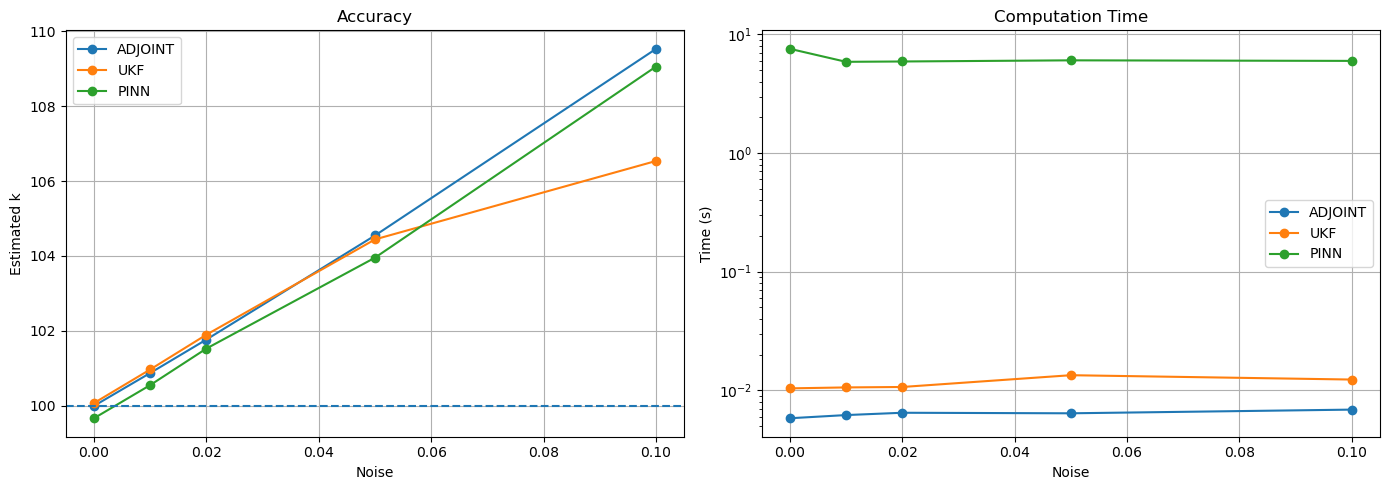

In [ ]:
# %% ==========================================
# FINAL FAIR COMPARISON (REVISED & CORRECTED)
# ADJOINT vs UKF vs PINN
# ==========================================
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from scipy.optimize import minimize
import time

torch.manual_seed(0)
np.random.seed(0)

# -----------------------------
# 1. Physics & Grid Setup
# -----------------------------
k_true = 100.0
Q0 = 10000.0
L = 1.0
T_left = 300.0
T_right = 500.0
dT = T_right - T_left

N = 100
x = np.linspace(0, L, N)
dx = x[1] - x[0]
x_in = x[1:-1]

Q_in = Q0 * (np.sin(np.pi*x_in/L) + 0.3*np.sin(2*np.pi*x_in/L))

diagonals = [np.ones(N-3), -2*np.ones(N-2), np.ones(N-3)]
D2 = diags(diagonals, [-1,0,1]).tocsr() / dx**2

b_bc = np.zeros(N-2)
b_bc[0] = T_left/dx**2
b_bc[-1] = T_right/dx**2

def solve_T(k):
    A = -k * D2
    rhs = Q_in + k * b_bc
    return spsolve(A, rhs)

T_true = solve_T(k_true)

# -----------------------------
# 2. Benchmark Setup
# -----------------------------
noise_levels = [0.0, 0.01, 0.02, 0.05, 0.1]
results_k = {"adjoint": [], "ukf": [], "pinn": []}
results_t = {"adjoint": [], "ukf": [], "pinn": []}

# =========================================================
# MASTER LOOP
# =========================================================
for noise_level in noise_levels:

    print(f"\n{'='*45}\nNoise Level = {noise_level}\n{'='*45}")

    np.random.seed(0)
    torch.manual_seed(0)

    noise = noise_level * np.std(T_true) * np.random.randn(N-2)
    T_obs = T_true + noise

    # =====================================================
    # METHOD 1: ADJOINT
    # =====================================================
    t0 = time.time()

    def obj_grad(k_array):
        k = k_array[0]
        T_pred = solve_T(k)

        r = T_pred - T_obs
        J = 0.5*np.sum(r**2)

        lam = spsolve(-k*D2, -r)
        dFdk = -D2.dot(T_pred) - b_bc
        grad = np.dot(lam, dFdk)

        return J, np.array([grad])

    k0 = 20.0

    res = minimize(obj_grad, [k0], method='L-BFGS-B',
                   jac=True, bounds=[(1,1000)], options={'maxiter':200})

    k_adj = res.x[0]
    time_adj = time.time() - t0

    # =====================================================
    # METHOD 2: UKF (FULL FIELD)
    # =====================================================
    t0 = time.time()

    def features(T):
        return (T - T_left)/dT  # FULL FIELD (fair)

    y_obs = features(T_obs)

    theta = np.array([np.log(20.0)])
    P = np.array([[0.5]])
    Q_cov = np.array([[1e-3]])
    R_cov = np.eye(len(y_obs)) * (noise_level**2 + 1e-4)

    alpha = 1e-3
    lam = alpha**2 - 1
    gamma = np.sqrt(1 + lam)

    Wm = np.full(3, 1/(2*(1+lam)))
    Wc = Wm.copy()
    Wm[0] = lam/(1+lam)
    Wc[0] = lam/(1+lam) + (1-alpha**2+2)

    for _ in range(20):

        Psqrt = np.linalg.cholesky(P + 1e-8*np.eye(1))

        sigma = np.vstack([
            theta,
            theta + gamma*Psqrt[:,0],
            theta - gamma*Psqrt[:,0]
        ])

        Y = np.array([features(solve_T(np.exp(s[0]))) for s in sigma])

        theta_pred = np.sum(Wm[:,None]*sigma, axis=0)

        P_pred = Q_cov.copy()
        for i in range(3):
            d = (sigma[i]-theta_pred).reshape(-1,1)
            P_pred += Wc[i]*(d@d.T)

        y_pred = np.sum(Wm[:,None]*Y, axis=0)

        S = R_cov.copy()
        C = np.zeros((1,len(y_obs)))

        for i in range(3):
            dy = (Y[i]-y_pred).reshape(-1,1)
            dx = (sigma[i]-theta_pred).reshape(-1,1)
            S += Wc[i]*(dy@dy.T)
            C += Wc[i]*(dx@dy.T)

        K = np.linalg.solve(S.T, C.T).T

        theta = theta_pred + K @ (y_obs - y_pred)
        P = P_pred - K@S@K.T

    k_ukf = np.exp(theta[0])
    time_ukf = time.time() - t0

    # =====================================================
    # METHOD 3: PINN 
    # =====================================================
    t0 = time.time()

    class PINN(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(1,64), nn.Tanh(),
                nn.Linear(64,64), nn.Tanh(),
                nn.Linear(64,1)
            )
            self.log_k = nn.Parameter(torch.tensor([np.log(50.0)]))

        def forward(self,x):
            x_star = x/L
            return x_star + x_star*(1-x_star)*self.net(x)

        def get_k(self):
            return torch.exp(self.log_k)

    model = PINN()

    x_data_t = torch.tensor(x_in, dtype=torch.float32).view(-1,1)
    theta_data_t = torch.tensor((T_obs - T_left)/dT, dtype=torch.float32).view(-1,1)

    x_f = torch.linspace(0,L,200).view(-1,1)
    x_f.requires_grad = True

    def get_losses():
        theta_pred = model(x_data_t)
        loss_data = torch.mean((theta_pred - theta_data_t)**2)

        theta = model(x_f)
        g = torch.autograd.grad(theta, x_f, torch.ones_like(theta), create_graph=True)[0]
        g2 = torch.autograd.grad(g, x_f, torch.ones_like(g), create_graph=True)[0]

        k = model.get_k()
        forcing = torch.sin(np.pi*x_f/L) + 0.3*torch.sin(2*np.pi*x_f/L)

        res = g2 + (Q0/(k*dT)) * forcing
        loss_phys = torch.mean(res**2)

        loss_reg = 1e-6 * model.log_k**2

        return loss_data, loss_phys, loss_reg

    # Stage 1: Data pretrain
    model.log_k.requires_grad = False
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    for _ in range(1000):
        opt.zero_grad()
        ld, lp, lr_reg = get_losses()
        loss = ld
        loss.backward()
        opt.step()

    # Stage 2: Inverse
    model.log_k.requires_grad = True
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    for _ in range(2000):
        opt.zero_grad()
        ld, lp, lr_reg = get_losses()
        loss = ld + 0.1*lp + lr_reg
        loss.backward()
        opt.step()

    # Stage 3: L-BFGS
    optimizer = torch.optim.LBFGS(model.parameters(), max_iter=300)

    def closure():
        optimizer.zero_grad()
        ld, lp, lr_reg = get_losses()
        loss = ld + lp + lr_reg
        loss.backward()
        return loss

    optimizer.step(closure)

    k_pinn = model.get_k().item()
    time_pinn = time.time() - t0

    # --- Store ---
    print(f"Adjoint : k = {k_adj:6.2f}  | Time = {time_adj:.3f}s")
    print(f"UKF     : k = {k_ukf:6.2f}  | Time = {time_ukf:.3f}s")
    print(f"PINN    : k = {k_pinn:6.2f}  | Time = {time_pinn:.3f}s")

    results_k["adjoint"].append(k_adj)
    results_k["ukf"].append(k_ukf)
    results_k["pinn"].append(k_pinn)

    results_t["adjoint"].append(time_adj)
    results_t["ukf"].append(time_ukf)
    results_t["pinn"].append(time_pinn)

# =========================================================
# PLOTS
# =========================================================
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,5))

for key in results_k:
    ax1.plot(noise_levels, results_k[key], marker='o', label=key.upper())

ax1.axhline(k_true, linestyle='--')
ax1.set_title("Accuracy")
ax1.set_xlabel("Noise")
ax1.set_ylabel("Estimated k")
ax1.legend()
ax1.grid()

for key in results_t:
    ax2.plot(noise_levels, results_t[key], marker='o', label=key.upper())

ax2.set_yscale('log')
ax2.set_title("Computation Time")
ax2.set_xlabel("Noise")
ax2.set_ylabel("Time (s)")
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()